In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import pgeocode
import shap
import lightgbm as lgb
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder

In [4]:
sold = pd.read_csv("C:/Users/44756/Documents/Postgrad/DSA8030/Data/sold_treated.csv", dtype = {'brokered_by':'string', 'street':'string', 'zip_code':'string'}, parse_dates = ['prev_sold_date'])
nomi = pgeocode.Nominatim('us')
location_data = nomi.query_postal_code(sold['zip_code'].tolist())
sold['latzip'] = location_data['latitude'].values
sold['longzip'] = location_data['longitude'].values
sold_dummy = pd.get_dummies(sold['state']).astype('int')
sold = pd.concat([sold, sold_dummy], axis = 1)
sold['cityfreq'] = sold['city'].map(sold['city'].value_counts())
sold['streetfreq'] = sold['street'].map(sold['street'].value_counts())
sold['brokerfreq'] = sold['brokered_by'].map(sold['brokered_by'].value_counts())
sold['otherstate_xgb'] = sold['state'].isin(['Vermont', 'Indiana', 'North Dakota', 'New Mexico', 'New Hampshire', 'Minnesota', 'Maine', 'Delaware', 'Alabama', 'Wyoming']).astype('int')
sold_train, sold_test = train_test_split(sold, test_size = 0.2, random_state=1)

In [5]:
model_rf = joblib.load("C:/Users/44756/Documents/Postgrad/DSA8030/model_rf.joblib")
model_xgb = joblib.load("C:/Users/44756/Documents/Postgrad/DSA8030/model_xgb.joblib")

XGBoost

R^2 0.849282895673609
RMSE 190172.85930588175
MAE 93090.49437727616
Positive residuals: 74762
Negative residuals: 86262
Average positive residual: 98951.70608546321
Average negative residual: -88010.66884891513
Average percentage error: 58.46266321998601


Text(0, 0.5, 'Predicted')

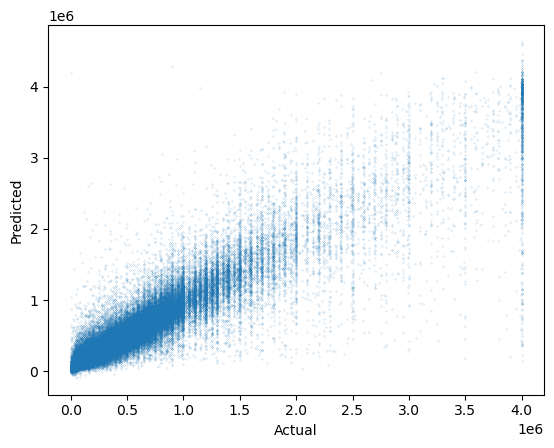

In [6]:
xgb_x = sold_test[['bed', 'bath', 'acre_lot', 'house_size', 'latzip', 'longzip', 'cityfreq', 'streetfreq', 'brokerfreq', 'precipitation', 'maxtemp', 'mintemp', 'avgtemp', 'po_box', 'population', 'density', 'dhighway', 'dlairport', 'dmairport', 'dshore', 'nobusiness', 'totalincome', 'adjustedincome', 'tax_returns','Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'District of Columbia', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maryland', 'Massachusetts', 'Michigan', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Jersey', 'New York', 'North Carolina', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'otherstate_xgb']]
xgb_y = sold_test['price']
xgb_pred = model_xgb.predict(xgb_x)

resids_xgb = xgb_y - xgb_pred
percenterror_xgb = (xgb_y - xgb_pred) / xgb_y
print('R^2', model_xgb.score(xgb_x, xgb_y))
print('RMSE', root_mean_squared_error(xgb_y, xgb_pred))
print('MAE', mean_absolute_error(xgb_y, xgb_pred))
print('Positive residuals:', len(resids_xgb[resids_xgb > 0]))
print('Negative residuals:', len(resids_xgb[resids_xgb < 0]))
print('Average positive residual:', np.mean(resids_xgb[resids_xgb > 0]))
print('Average negative residual:', np.mean(resids_xgb[resids_xgb < 0]))
print('Average percentage error:', np.mean(abs(percenterror_xgb)))
plt.scatter(xgb_y, xgb_pred, s = 0.01)
plt.xlabel('Actual')
plt.ylabel('Predicted')

In [8]:
explainer_xgb = shap.TreeExplainer(model_xgb)
shap_values_xgb = explainer_xgb.shap_values(xgb_x)

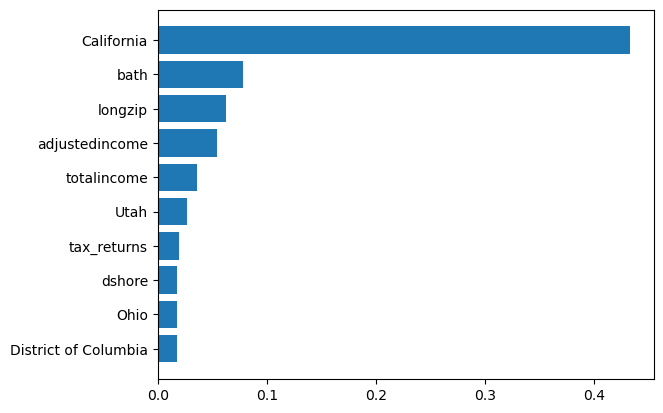

In [78]:
sorted_idx = model_xgb.feature_importances_.argsort()
# plt.figure(figsize=(10,15))
plt.barh(model_xgb.feature_names_in_[sorted_idx][-10:], model_xgb.feature_importances_[sorted_idx][-10:])
plt.show()

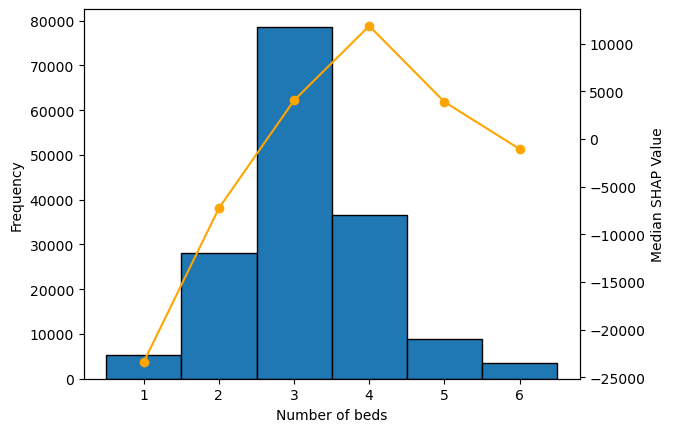

In [21]:
# Bed univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.bed, ec = 'black', bins = np.arange(0.5,7.5))
shaps = [np.median(shap_values_xgb[xgb_x.bed == x, 0]) for x in np.arange(1,7)]
ax.set_xticks(ticks = np.arange(0,7), labels = np.arange(0,7))
ax.set_xlabel('Number of beds')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(np.arange(1,7), shaps, color = 'orange')
ax2.scatter(np.arange(1,7), shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

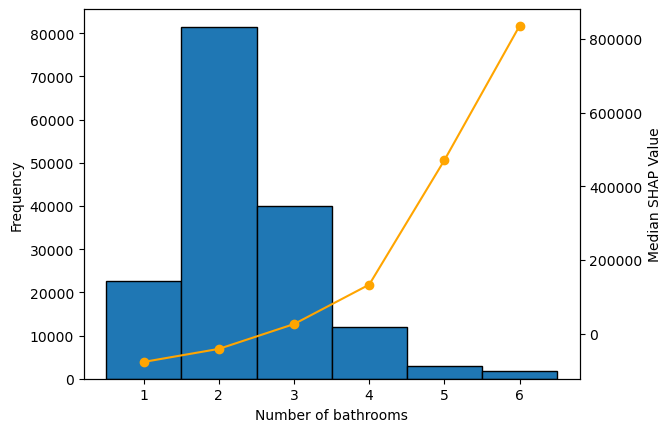

In [38]:
# Bath univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.bath, ec = 'black', bins = np.arange(0.5,7.5))
shaps = [np.median(shap_values_xgb[xgb_x.bath == x, 1]) for x in np.arange(1,7)]
ax.set_xticks(ticks = np.arange(0,7), labels = np.arange(0,7))
ax.set_xlabel('Number of bathrooms')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(np.arange(1,7), shaps, color = 'orange')
ax2.scatter(np.arange(1,7), shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

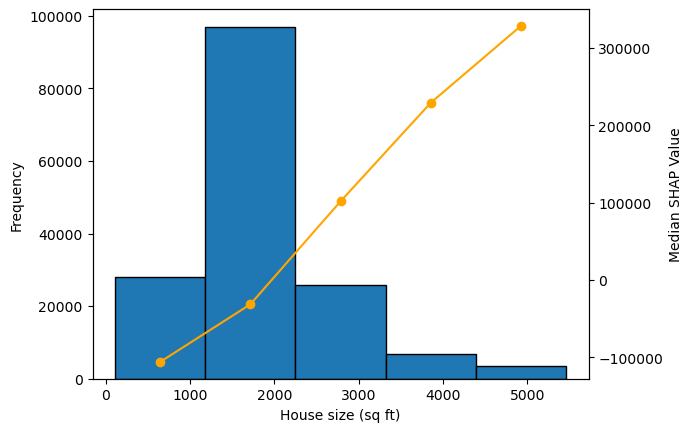

In [20]:
# House size univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.house_size, ec = 'black', bins = 5)
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.house_size >= hist[1][x]) & (xgb_x.house_size < hist[1][x+1]), 3]) for x in range(len(hist[1])-1)]
ax.set_xlabel('House size (sq ft)')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

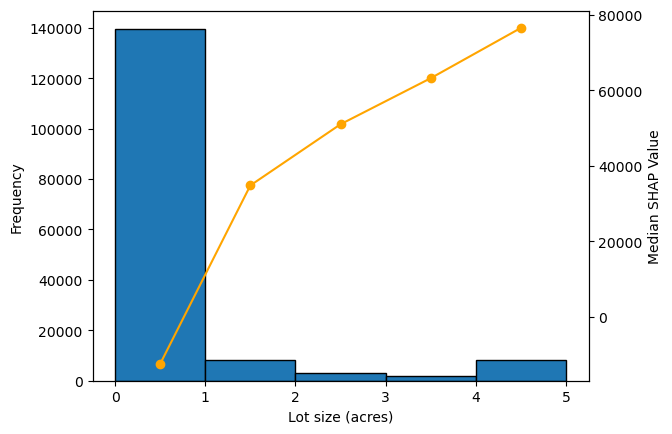

In [41]:
# Acre lot univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.acre_lot, ec = 'black', bins = 5)
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.acre_lot >= hist[1][x]) & (xgb_x.acre_lot < hist[1][x+1]), 2]) for x in range(len(hist[1])-1)]
ax.set_xlabel('Lot size (acres)')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

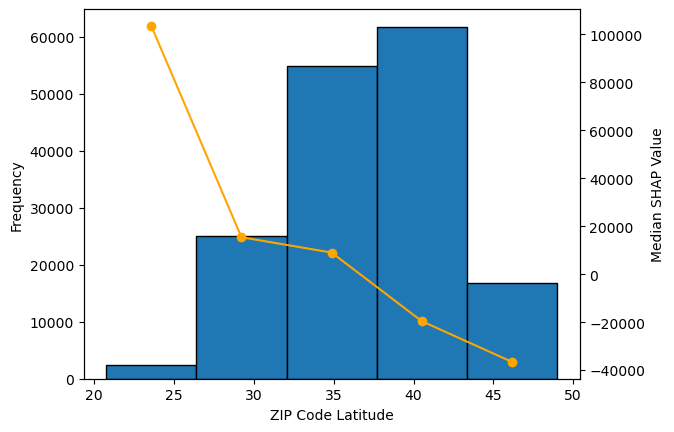

In [42]:
# ZIP latitude univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.latzip, ec = 'black', bins = 5)
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.latzip >= hist[1][x]) & (xgb_x.latzip < hist[1][x+1]), 4]) for x in range(len(hist[1])-1)]
ax.set_xlabel('ZIP Code Latitude')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

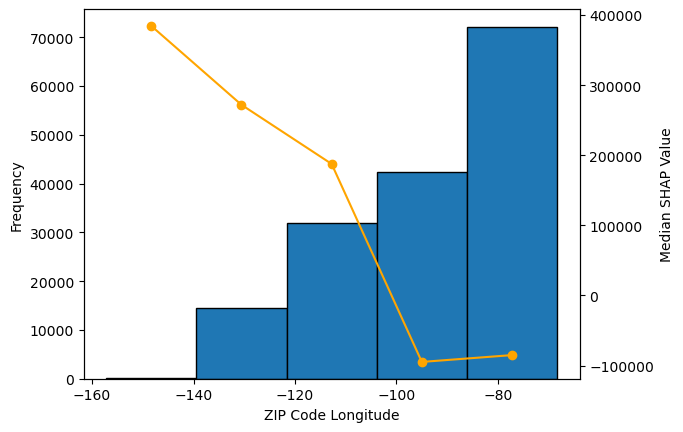

In [43]:
# ZIP longitude univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.longzip, ec = 'black', bins = 5)
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.longzip >= hist[1][x]) & (xgb_x.longzip < hist[1][x+1]), 5]) for x in range(len(hist[1])-1)]
ax.set_xlabel('ZIP Code Longitude')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

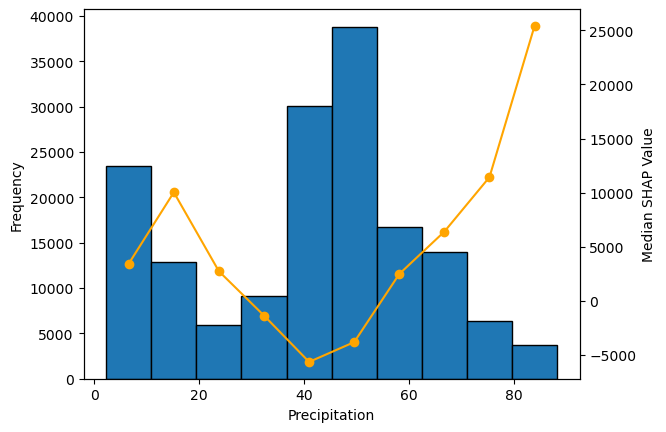

In [44]:
# Precipitation univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.precipitation, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.precipitation >= hist[1][x]) & (xgb_x.precipitation < hist[1][x+1]), 9]) for x in range(len(hist[1])-1)]
ax.set_xlabel('Precipitation')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

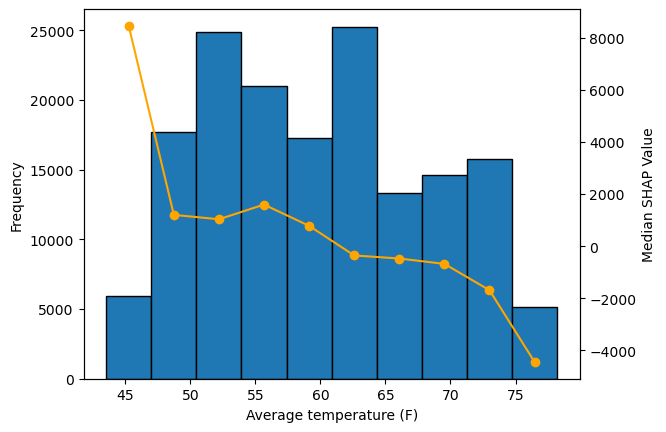

In [45]:
# Avg temp univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.avgtemp, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.avgtemp >= hist[1][x]) & (xgb_x.avgtemp < hist[1][x+1]), 12]) for x in range(len(hist[1])-1)]
ax.set_xlabel('Average temperature (F)')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

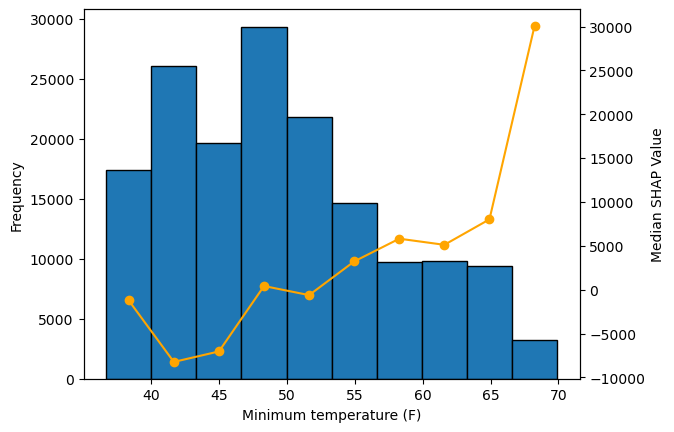

In [46]:
# Min temp univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.mintemp, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.mintemp >= hist[1][x]) & (xgb_x.mintemp < hist[1][x+1]), 11]) for x in range(len(hist[1])-1)]
ax.set_xlabel('Minimum temperature (F)')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

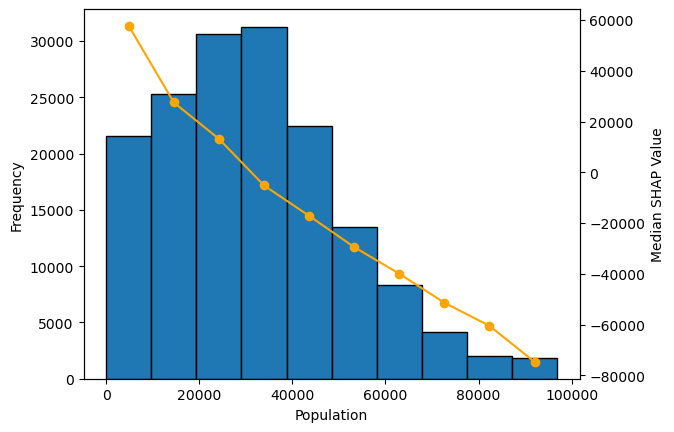

In [59]:
# Population univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.population, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.population >= hist[1][x]) & (xgb_x.population < hist[1][x+1]), 14]) for x in range(len(hist[1])-1)]
ax.set_xlabel('Population')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

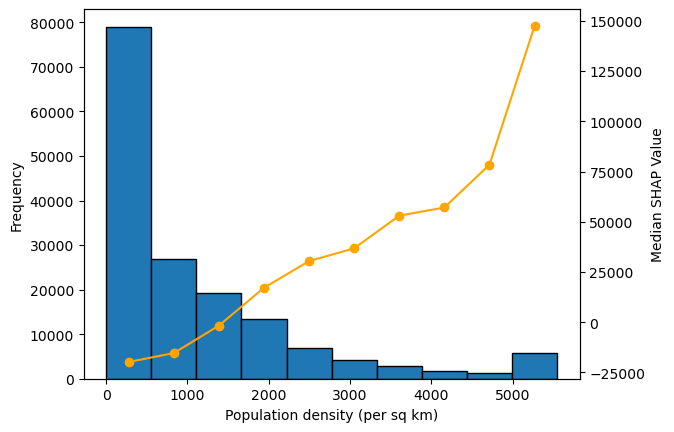

In [58]:
# Population density univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.density, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.density >= hist[1][x]) & (xgb_x.density < hist[1][x+1]), 15]) for x in range(len(hist[1])-1)]
ax.set_xlabel('Population density (per sq km)')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

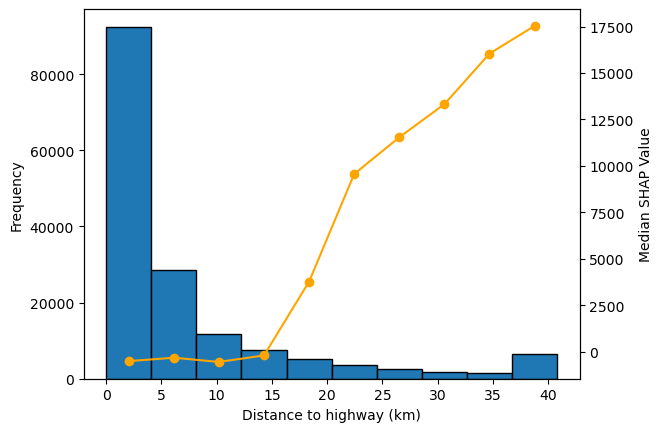

In [57]:
# Distance to highway univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.dhighway, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.dhighway >= hist[1][x]) & (xgb_x.dhighway < hist[1][x+1]), 16]) for x in range(len(hist[1])-1)]
ax.set_xlabel('Distance to highway (km)')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

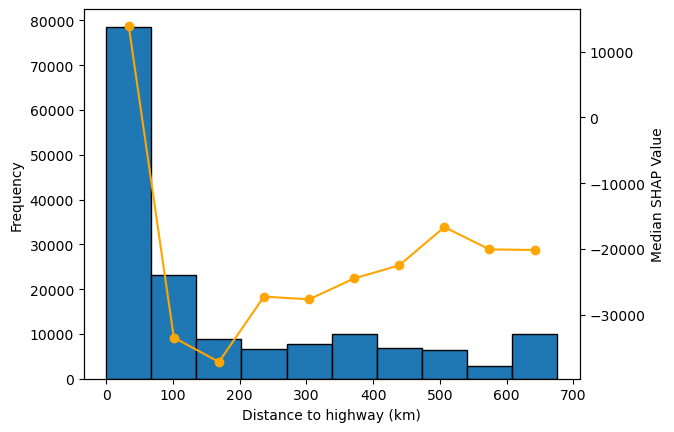

In [60]:
# Distance to shoreline univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.dshore, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.dshore >= hist[1][x]) & (xgb_x.dshore < hist[1][x+1]), 19]) for x in range(len(hist[1])-1)]
ax.set_xlabel('Distance to highway (km)')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

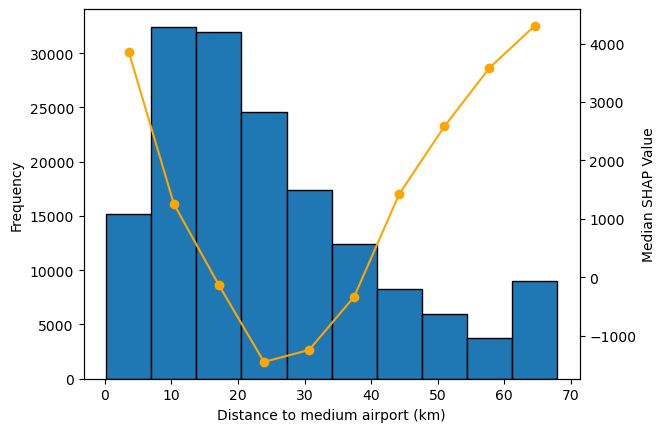

In [62]:
# Distance to medium airport univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.dmairport, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.dmairport >= hist[1][x]) & (xgb_x.dmairport < hist[1][x+1]), 18]) for x in range(len(hist[1])-1)]
ax.set_xlabel('Distance to medium airport (km)')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

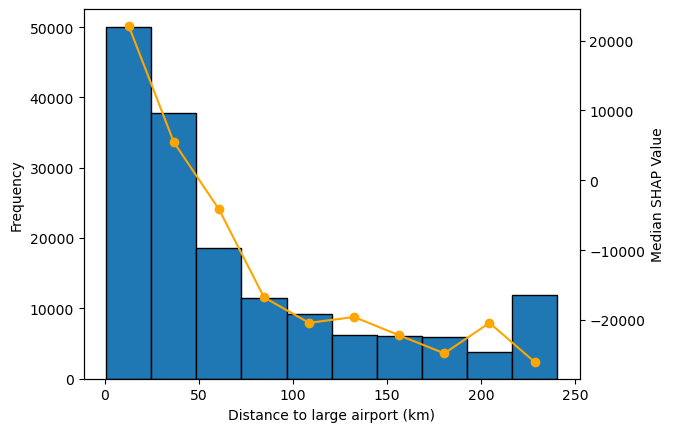

In [64]:
# Distance to large airport univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.dlairport, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.dlairport >= hist[1][x]) & (xgb_x.dlairport < hist[1][x+1]), 17]) for x in range(len(hist[1])-1)]
ax.set_xlabel('Distance to large airport (km)')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

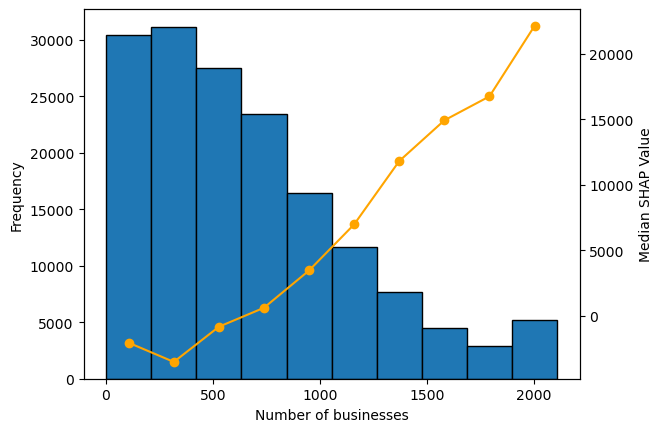

In [67]:
# Number of businesses univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.nobusiness, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.nobusiness >= hist[1][x]) & (xgb_x.nobusiness < hist[1][x+1]), 20]) for x in range(len(hist[1])-1)]
ax.set_xlabel('Number of businesses')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

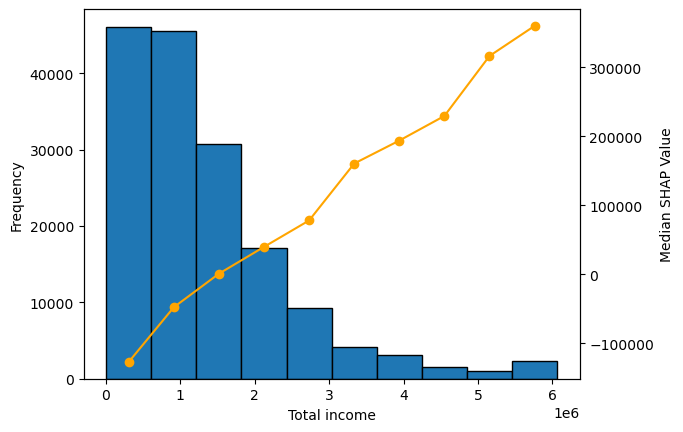

In [69]:
# Total income univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.totalincome, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.totalincome >= hist[1][x]) & (xgb_x.totalincome < hist[1][x+1]), 21]) for x in range(len(hist[1])-1)]
ax.set_xlabel('Total income')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

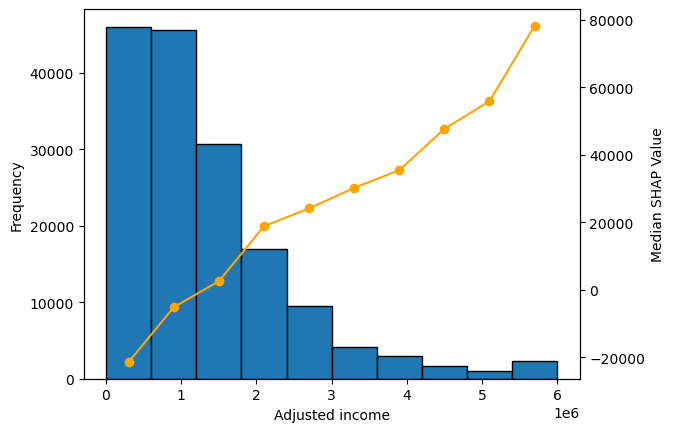

In [70]:
# Adjusted income univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.adjustedincome, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.adjustedincome >= hist[1][x]) & (xgb_x.adjustedincome < hist[1][x+1]), 22]) for x in range(len(hist[1])-1)]
ax.set_xlabel('Adjusted income')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

In [88]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(pd.DataFrame([model_xgb.feature_names_in_, model_xgb.feature_importances_]).T.sort_values(1, ascending = False))
pd.reset_option('display.max_columns')

,0,1
26,California,0.433261
1,bath,0.078046
5,longzip,0.06239
22,adjustedincome,0.053985
21,totalincome,0.035861
59,Utah,0.02717
23,tax_returns,0.019224
19,dshore,0.018077
50,Ohio,0.017946
29,District of Columbia,0.017534


In [98]:
print(np.median(xgb_pred[sold_test.California == 1]),np.median(xgb_pred[sold_test.California == 0]))

697435.4 309524.75


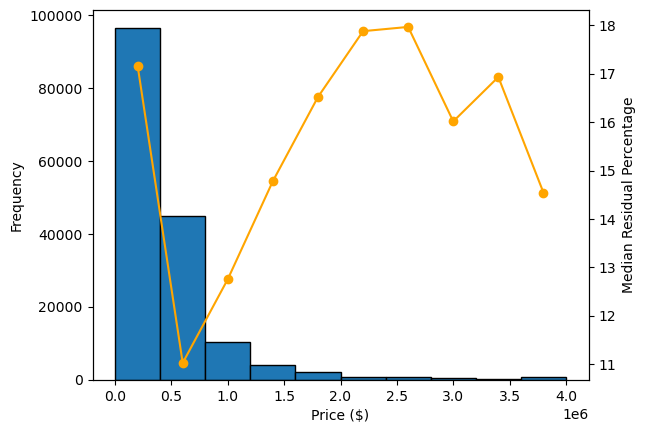

In [99]:
# XGB %age error univariate
fig, ax = plt.subplots()

hist = ax.hist(sold_test.price, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
prices = [np.abs(percenterror_xgb[(sold_test.price >= hist[1][x]) & (sold_test.price < hist[1][x+1])]).median() * 100 for x in range(len(hist[1])-1)]
ax.set_xlabel('Price ($)')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, prices, color = 'orange')
ax2.scatter(midpts, prices, color = 'orange')
ax2.set_ylabel('Median Residual Percentage')
plt.show()

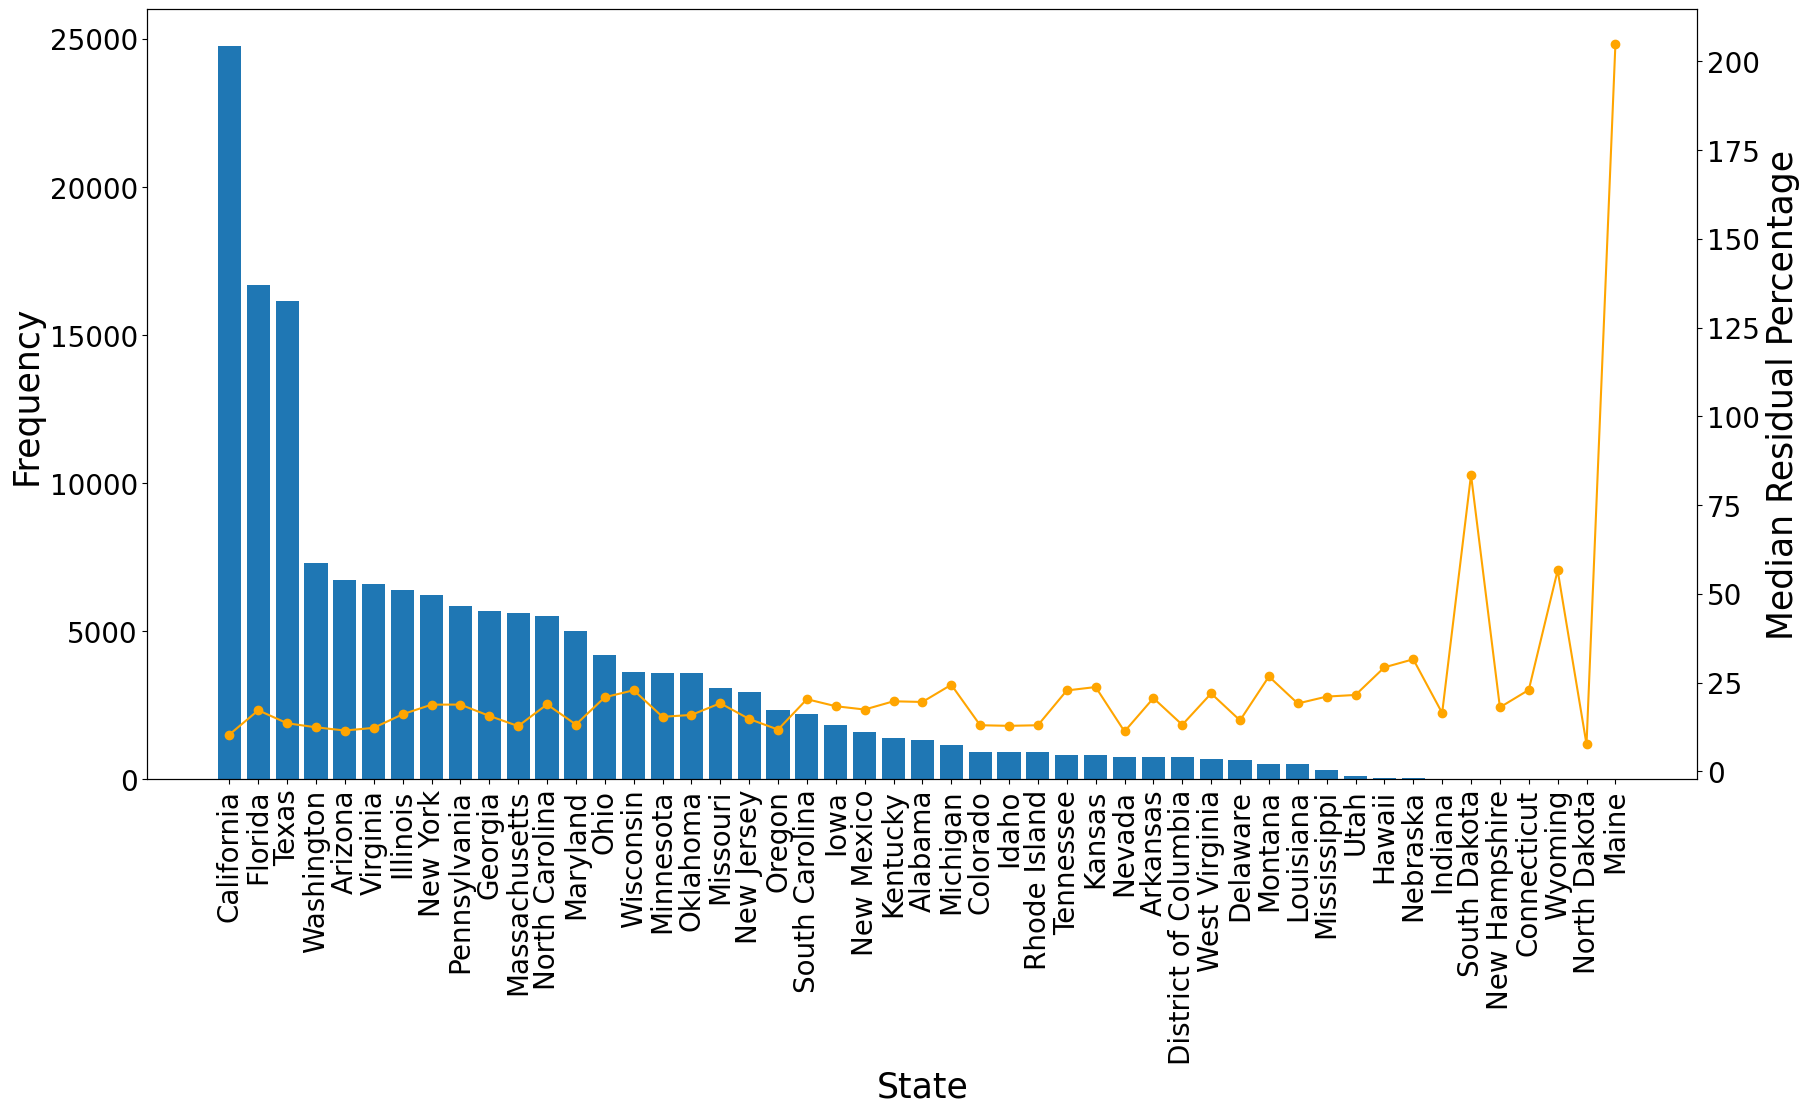

In [82]:
# XGB states %age error
fig, ax = plt.subplots(figsize=(20,10))

states = sold_test.groupby('state').describe()['price'].sort_values(by = 'count', ascending = False).index.tolist()
freq = [len(sold_test[sold_test['state'] == st]) for st in states]
prices = [np.abs(percenterror_xgb[sold_test.state == st]).median() * 100 for st in states]

ax.bar(states, freq)
ax.tick_params(axis='both', labelsize = '20')
ax.set_xlabel('State', fontsize = 25)
ax.set_ylabel('Frequency', fontsize = 25)
plt.xticks(rotation = 90)
ax2 = ax.twinx()
ax2.tick_params(axis='both', labelsize = '20')
ax2.plot(states, prices, color = 'orange')
ax2.scatter(states, prices, color = 'orange')
ax2.set_ylabel('Median Residual Percentage', fontsize = 25)
# ax2.set_yticks(ticks = [200000,400000,600000,800000,1000000], labels = [0.2,0.4,0.6,0.8,1.0])
# plt.tight_layout()
# plt.savefig('C:/Users/44756/Documents/Postgrad/DSA8030/states.pdf')
plt.show()

RandomForestRegressor

R^2 0.8410817670992683
RMSE 195278.3645046487
MAE 92171.00902871591
Positive residuals: 72215
Negative residuals: 88800
Average positive residual: 99551.9918372913
Average negative residual: -86177.89940664369
Average percentage error: 57.418330934896915


Text(0, 0.5, 'Predicted')

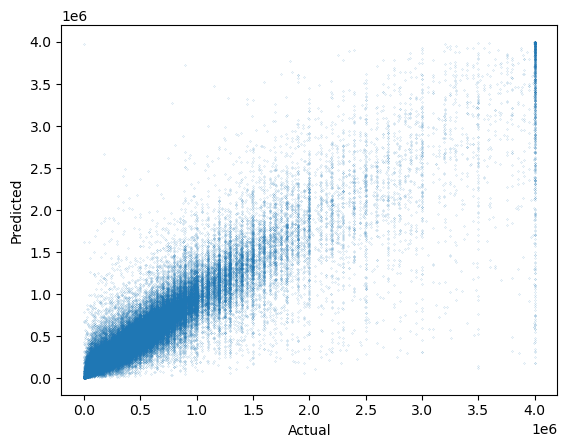

In [7]:
rf_x = sold_test[['bed', 'bath', 'acre_lot', 'house_size', 'latzip', 'longzip', 'cityfreq', 'streetfreq', 'brokerfreq', 'precipitation', 'maxtemp', 'mintemp', 'avgtemp', 'po_box', 'population', 'density', 'dhighway', 'dlairport', 'dmairport', 'dshore', 'nobusiness', 'totalincome', 'adjustedincome', 'tax_returns', 'Alabama', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']]
rf_y = sold_test['price']
rf_pred = model_rf.predict(rf_x)

resids_rf = rf_y - rf_pred
percenterror_rf = (rf_y - rf_pred) / rf_y
print('R^2', model_rf.score(rf_x, rf_y))
print('RMSE', root_mean_squared_error(rf_y, rf_pred))
print('MAE', mean_absolute_error(rf_y, rf_pred))
print('Positive residuals:', len(resids_rf[resids_rf > 0]))
print('Negative residuals:', len(resids_rf[resids_rf < 0]))
print('Average positive residual:', np.mean(resids_rf[resids_rf > 0]))
print('Average negative residual:', np.mean(resids_rf[resids_rf < 0]))
print('Average percentage error:', np.mean(abs(percenterror_rf)))
plt.scatter(rf_y, rf_pred, s = 0.01)
plt.xlabel('Actual')
plt.ylabel('Predicted')